<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter5_Matrix_Multiplication_and_Matrix_Vector_Multiplication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 - Matrix Multiplication and Matrix–Vector Multiplication

Notebook ini membahas operasi **perkalian matriks** dan **perkalian matriks-vektor** dalam linear algebra untuk data science, berdasarkan buku **Practical Linear Algebra for Data Science** karya **Mike X. Cohen**.

Fokus utama chapter ini adalah:
- memahami aturan dasar perkalian matriks,
- membedakan perkalian elemen per elemen dan perkalian matriks,
- memahami syarat shape agar dua matriks bisa dikalikan,
- melakukan perkalian matriks-vektor,
- memahami makna geometris dari hasil perkalian,
- melihat bagaimana perkalian matriks digunakan dalam machine learning,
- serta menghubungkan operasi ini dengan transformasi data dan model linear.

Perkalian matriks adalah salah satu operasi paling penting dalam data science, karena banyak algoritma machine learning, optimisasi, dan neural network bekerja dengan operasi ini.


## 1. Import Library

Pada chapter ini kita menggunakan:
- **NumPy** untuk operasi matriks dan vektor
- **Pandas** untuk menampilkan hasil dalam tabel
- **Matplotlib** dan **Seaborn** untuk visualisasi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.set_printoptions(suppress=True, precision=4)

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Review Singkat Matriks dan Vektor

Sebelum masuk ke perkalian matriks, kita ingat kembali:
- **vektor** adalah array satu dimensi
- **matriks** adalah array dua dimensi yang terdiri dari baris dan kolom

Dalam data science:
- vektor sering merepresentasikan satu fitur, satu sampel, atau parameter model
- matriks sering merepresentasikan seluruh dataset

In [2]:
v = np.array([1, 2, 3])

A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("Vektor v:")
print(v)
print("Shape v:", v.shape)

print("\nMatriks A:")
print(A)
print("Shape A:", A.shape)

Vektor v:
[1 2 3]
Shape v: (3,)

Matriks A:
[[1 2 3]
 [4 5 6]]
Shape A: (2, 3)


## 3. Perbedaan Perkalian Elemen per Elemen dan Perkalian Matriks

Ada dua jenis perkalian yang perlu dibedakan:

### a. Perkalian elemen per elemen
Dilakukan pada elemen yang posisinya sama.
Di NumPy, operator `*` pada dua array dengan shape yang sama melakukan perkalian elemen per elemen.

### b. Perkalian matriks
Menggunakan aturan aljabar linear.
Di NumPy dapat dilakukan dengan:
- operator `@`
- fungsi `np.dot()`
- fungsi `np.matmul()`

Kedua jenis perkalian ini **tidak sama**.

In [3]:
M1 = np.array([
    [1, 2],
    [3, 4]
])

M2 = np.array([
    [5, 6],
    [7, 8]
])

elem_mult = M1 * M2
mat_mult = M1 @ M2

print("M1:")
print(M1)

print("\nM2:")
print(M2)

print("\nPerkalian elemen per elemen (M1 * M2):")
print(elem_mult)

print("\nPerkalian matriks (M1 @ M2):")
print(mat_mult)

M1:
[[1 2]
 [3 4]]

M2:
[[5 6]
 [7 8]]

Perkalian elemen per elemen (M1 * M2):
[[ 5 12]
 [21 32]]

Perkalian matriks (M1 @ M2):
[[19 22]
 [43 50]]


## 4. Aturan Dasar Perkalian Matriks

Misalkan:
- matriks A berukuran **m × n**
- matriks B berukuran **n × p**

Maka:
- hasil perkalian `A @ B` valid
- hasilnya akan berukuran **m × p**

### Syarat utama:
Jumlah kolom matriks pertama harus sama dengan jumlah baris matriks kedua.

Contoh:
- A berukuran 2×3
- B berukuran 3×4

Maka A @ B valid dan hasilnya berukuran 2×4.

In [4]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

C = A @ B

print("Shape A:", A.shape)
print("Shape B:", B.shape)
print("Shape hasil A @ B:", C.shape)

print("\nHasil A @ B:")
print(C)

Shape A: (2, 3)
Shape B: (3, 2)
Shape hasil A @ B: (2, 2)

Hasil A @ B:
[[22 28]
 [49 64]]


## 5. Mengapa Shape Sangat Penting?

Perkalian matriks **tidak bisa dilakukan sembarangan**.  
Jika shape tidak sesuai, NumPy akan menghasilkan error.

Kita akan lihat contoh:
- matriks 2×3
- matriks 2×2

Karena jumlah kolom matriks pertama = 3, sedangkan jumlah baris matriks kedua = 2, maka keduanya **tidak kompatibel** untuk dikalikan.

In [5]:
A_bad = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

B_bad = np.array([
    [1, 2],
    [3, 4]
])

print("Shape A_bad:", A_bad.shape)
print("Shape B_bad:", B_bad.shape)
print("\nA_bad tidak bisa dikalikan dengan B_bad karena jumlah kolom A_bad != jumlah baris B_bad.")

Shape A_bad: (2, 3)
Shape B_bad: (2, 2)

A_bad tidak bisa dikalikan dengan B_bad karena jumlah kolom A_bad != jumlah baris B_bad.


## 6. Ilustrasi Manual Perkalian Matriks

Misalkan:

A = [[1, 2],
     [3, 4]]

B = [[5, 6],
     [7, 8]]

Maka elemen hasil perkalian matriks dihitung dengan:
- baris dari A dikalikan dengan kolom dari B

Contoh elemen kiri atas:
(1×5) + (2×7) = 19

Elemen kanan atas:
(1×6) + (2×8) = 22

Dan seterusnya.

In [6]:
A_small = np.array([
    [1, 2],
    [3, 4]
])

B_small = np.array([
    [5, 6],
    [7, 8]
])

C_small = A_small @ B_small

print("A_small:")
print(A_small)

print("\nB_small:")
print(B_small)

print("\nHasil A_small @ B_small:")
print(C_small)

A_small:
[[1 2]
 [3 4]]

B_small:
[[5 6]
 [7 8]]

Hasil A_small @ B_small:
[[19 22]
 [43 50]]


## 7. Verifikasi Manual Satu Elemen Hasil

Mari kita hitung elemen hasil posisi [0,0] secara manual.

Jika:
A = [[1, 2],
     [3, 4]]

B = [[5, 6],
     [7, 8]]

Maka:
hasil[0,0] = (1×5) + (2×7) = 19

In [7]:
manual_00 = A_small[0,0]*B_small[0,0] + A_small[0,1]*B_small[1,0]
manual_01 = A_small[0,0]*B_small[0,1] + A_small[0,1]*B_small[1,1]

print("Perhitungan manual elemen [0,0]:", manual_00)
print("Perhitungan manual elemen [0,1]:", manual_01)

print("\nBaris pertama hasil A_small @ B_small:")
print(C_small[0])

Perhitungan manual elemen [0,0]: 19
Perhitungan manual elemen [0,1]: 22

Baris pertama hasil A_small @ B_small:
[19 22]


## 8. Perkalian Matriks dengan Operator @

Di NumPy, cara paling praktis untuk melakukan perkalian matriks adalah menggunakan operator `@`.

In [8]:
A = np.array([
    [2, 1],
    [0, 3]
])

B = np.array([
    [4, 5],
    [6, 7]
])

result_at = A @ B
print(result_at)

[[14 17]
 [18 21]]


## 9. Perkalian Matriks dengan np.dot() dan np.matmul()

Selain `@`, NumPy menyediakan:
- `np.dot(A, B)`
- `np.matmul(A, B)`

Untuk matriks 2D, ketiganya memberikan hasil yang sama.

In [9]:
result_dot = np.dot(A, B)
result_matmul = np.matmul(A, B)

comparison = pd.DataFrame({
    "Metode": ["A @ B", "np.dot(A,B)", "np.matmul(A,B)"],
    "Hasil": [result_at.tolist(), result_dot.tolist(), result_matmul.tolist()]
})

comparison

,Metode,Hasil
0,A @ B,"[[14, 17], [18, 21]]"
1,"np.dot(A,B)","[[14, 17], [18, 21]]"
2,"np.matmul(A,B)","[[14, 17], [18, 21]]"


## 10. Perkalian Matriks-Vektor

Jika:
- A adalah matriks berukuran m×n
- v adalah vektor panjang n

Maka perkalian `A @ v` valid, dan hasilnya adalah vektor panjang m.

Ini sangat penting dalam machine learning karena:
- satu matriks fitur dapat dikalikan dengan vektor bobot
- hasilnya menjadi skor prediksi

In [10]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

v = np.array([10, 20, 30])

result_mv = A @ v

print("Matriks A:")
print(A)
print("Shape A:", A.shape)

print("\nVektor v:")
print(v)
print("Shape v:", v.shape)

print("\nHasil A @ v:")
print(result_mv)
print("Shape hasil:", result_mv.shape)

Matriks A:
[[1 2 3]
 [4 5 6]]
Shape A: (2, 3)

Vektor v:
[10 20 30]
Shape v: (3,)

Hasil A @ v:
[140 320]
Shape hasil: (2,)


## 11. Memahami Perkalian Matriks-Vektor Secara Manual

Untuk matriks:

A = [[1, 2, 3],
     [4, 5, 6]]

dan vektor:
v = [10, 20, 30]

maka hasil:
A @ v

dihitung sebagai:
- baris pertama A dikalikan dengan v
- baris kedua A dikalikan dengan v

Baris pertama:
(1×10) + (2×20) + (3×30) = 140

Baris kedua:
(4×10) + (5×20) + (6×30) = 320

In [11]:
manual_row1 = 1*10 + 2*20 + 3*30
manual_row2 = 4*10 + 5*20 + 6*30

print("Perhitungan manual hasil A @ v:")
print([manual_row1, manual_row2])

print("\nHasil NumPy:")
print(result_mv)

Perhitungan manual hasil A @ v:
[140, 320]

Hasil NumPy:
[140 320]


## 12. Visualisasi Matriks-Vektor sebagai Kombinasi Linear

Perkalian matriks-vektor dapat dipandang sebagai kombinasi linear dari kolom-kolom matriks.

Jika:
A = [a1 a2 a3]
dan
v = [x1, x2, x3]

maka:
A @ v = x1*a1 + x2*a2 + x3*a3

Artinya hasil akhir adalah gabungan kolom matriks yang diberi bobot oleh elemen-elemen vektor.

In [12]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

v = np.array([10, 20, 30])

a1 = A[:,0]
a2 = A[:,1]
a3 = A[:,2]

linear_comb = 10*a1 + 20*a2 + 30*a3

print("Kolom 1:", a1)
print("Kolom 2:", a2)
print("Kolom 3:", a3)

print("\nHasil kombinasi linear:")
print(linear_comb)

print("\nHasil A @ v:")
print(A @ v)

Kolom 1: [1 4]
Kolom 2: [2 5]
Kolom 3: [3 6]

Hasil kombinasi linear:
[140 320]

Hasil A @ v:
[140 320]


## 13. Perkalian Vektor-Matriks

Selain `A @ v`, kita juga bisa memiliki bentuk `v @ A`, asalkan shape-nya sesuai.

Jika:
- v adalah vektor panjang m
- A adalah matriks m×n

maka hasil `v @ A` adalah vektor panjang n.

In [13]:
v_left = np.array([2, 3])

A_left = np.array([
    [1, 4, 7],
    [2, 5, 8]
])

result_vm = v_left @ A_left

print("v_left:", v_left)
print("Shape v_left:", v_left.shape)

print("\nA_left:")
print(A_left)
print("Shape A_left:", A_left.shape)

print("\nHasil v_left @ A_left:")
print(result_vm)

v_left: [2 3]
Shape v_left: (2,)

A_left:
[[1 4 7]
 [2 5 8]]
Shape A_left: (2, 3)

Hasil v_left @ A_left:
[ 8 23 38]


## 14. Contoh Perkalian Matriks dengan Shape Lebih Besar

Sekarang kita coba matriks yang lebih besar agar terlihat pola ukuran hasilnya.

In [14]:
np.random.seed(10)

A_big = np.random.randint(1, 10, size=(3, 4))
B_big = np.random.randint(1, 10, size=(4, 2))

C_big = A_big @ B_big

print("A_big shape:", A_big.shape)
print(A_big)

print("\nB_big shape:", B_big.shape)
print(B_big)

print("\nC_big = A_big @ B_big")
print("Shape C_big:", C_big.shape)
print(C_big)

A_big shape: (3, 4)
[[5 1 2 1]
 [2 9 1 9]
 [7 5 4 1]]

B_big shape: (4, 2)
[[5 7]
 [9 2]
 [9 5]
 [2 4]]

C_big = A_big @ B_big
Shape C_big: (3, 2)
[[ 54  51]
 [118  73]
 [118  83]]


## 15. Membaca Ukuran Hasil Tanpa Menghitung

Jika:
- A berukuran 3×4
- B berukuran 4×2

Maka:
- hasil A @ B akan berukuran 3×2

Cara cepat:
- ukuran “bagian dalam” harus sama → 4 dan 4
- ukuran hasil adalah “bagian luar” → 3×2

In [15]:
shape_df = pd.DataFrame({
    "Matriks": ["A_big", "B_big", "C_big = A_big @ B_big"],
    "Shape": [A_big.shape, B_big.shape, C_big.shape]
})

shape_df

,Matriks,Shape
0,A_big,"(3, 4)"
1,B_big,"(4, 2)"
2,C_big = A_big @ B_big,"(3, 2)"


## 16. Perkalian Matriks dengan Matriks Identitas

Matriks identitas bertindak seperti angka 1 pada perkalian biasa.

Jika I adalah matriks identitas dengan ukuran yang sesuai, maka:
- A @ I = A
- I @ A = A

In [16]:
A = np.array([
    [3, 1],
    [7, 2]
])

I = np.eye(2)

print("A:")
print(A)

print("\nI:")
print(I)

print("\nA @ I:")
print(A @ I)

print("\nI @ A:")
print(I @ A)

A:
[[3 1]
 [7 2]]

I:
[[1. 0.]
 [0. 1.]]

A @ I:
[[3. 1.]
 [7. 2.]]

I @ A:
[[3. 1.]
 [7. 2.]]


## 17. Perkalian Matriks dengan Matriks Nol

Jika sebuah matriks dikalikan dengan matriks nol berukuran sesuai, hasilnya akan menjadi matriks nol.

In [17]:
A = np.array([
    [1, 2],
    [3, 4]
])

Z = np.zeros((2, 2))

print("A @ Z:")
print(A @ Z)

print("\nZ @ A:")
print(Z @ A)

A @ Z:
[[0. 0.]
 [0. 0.]]

Z @ A:
[[0. 0.]
 [0. 0.]]


## 18. Sifat Umum Perkalian Matriks

Beberapa sifat penting:

1. **Asosiatif**
   - `(A @ B) @ C = A @ (B @ C)`

2. **Distributif**
   - `A @ (B + C) = A @ B + A @ C`

3. **Tidak komutatif secara umum**
   - biasanya `A @ B != B @ A`

Sifat ketiga sangat penting: urutan perkalian matriks biasanya memengaruhi hasil.

In [18]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 0], [1, 2]])
C = np.array([[0, 1], [5, 3]])

left_assoc = (A @ B) @ C
right_assoc = A @ (B @ C)

print("Apakah asosiatif berlaku?", np.allclose(left_assoc, right_assoc))
print("\n(A @ B) @ C:")
print(left_assoc)
print("\nA @ (B @ C):")
print(right_assoc)

Apakah asosiatif berlaku? True

(A @ B) @ C:
[[20 16]
 [40 34]]

A @ (B @ C):
[[20 16]
 [40 34]]


## 19. Verifikasi Sifat Distributif

Kita cek apakah:
A @ (B + C) = A @ B + A @ C

In [19]:
left_dist = A @ (B + C)
right_dist = (A @ B) + (A @ C)

print("A @ (B + C):")
print(left_dist)

print("\n(A @ B) + (A @ C):")
print(right_dist)

print("\nApakah sama?", np.allclose(left_dist, right_dist))

A @ (B + C):
[[14 11]
 [30 23]]

(A @ B) + (A @ C):
[[14 11]
 [30 23]]

Apakah sama? True


## 20. Matriks Tidak Komutatif

Sekarang kita cek apakah:
A @ B = B @ A

Pada umumnya hasilnya berbeda.

In [20]:
AB = A @ B
BA = B @ A

print("A @ B:")
print(AB)

print("\nB @ A:")
print(BA)

print("\nApakah A @ B sama dengan B @ A?", np.allclose(AB, BA))

A @ B:
[[ 4  4]
 [10  8]]

B @ A:
[[ 2  4]
 [ 7 10]]

Apakah A @ B sama dengan B @ A? False


## 21. Perkalian Matriks dan Sistem Prediksi Linear

Dalam machine learning, salah satu bentuk paling penting adalah:

y_hat = X @ w

di mana:
- `X` = matriks fitur
- `w` = vektor bobot
- `y_hat` = hasil prediksi

Ini adalah fondasi dari:
- linear regression
- logistic regression
- neural network layer linear

In [21]:
X = np.array([
    [1.2, 3.5],
    [2.0, 1.0],
    [0.5, 4.0],
    [3.0, 2.5]
])

w = np.array([2.0, -1.0])

y_hat = X @ w

X_df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
pred_df = pd.DataFrame({
    "Prediksi": y_hat
})

print("Matriks fitur X:")
display(X_df)

print("Vektor bobot w:")
print(w)

print("\nHasil prediksi y_hat = X @ w:")
display(pred_df)

Matriks fitur X:


,feature_1,feature_2
0,1.2,3.5
1,2.0,1.0
2,0.5,4.0
3,3.0,2.5


Vektor bobot w:
[ 2. -1.]

Hasil prediksi y_hat = X @ w:


,Prediksi
0,-1.1
1,3.0
2,-3.0
3,3.5


## 22. Memahami y_hat = X @ w

Misalkan untuk baris pertama:
X[0] = [1.2, 3.5]
w = [2.0, -1.0]

Maka:
y_hat[0] = (1.2 × 2.0) + (3.5 × -1.0)
         = 2.4 - 3.5
         = -1.1

Setiap baris pada matriks fitur akan dikalikan dengan vektor bobot untuk menghasilkan satu nilai prediksi.

In [22]:
manual_pred_1 = X[0,0]*w[0] + X[0,1]*w[1]

print("Perhitungan manual prediksi sampel pertama:", manual_pred_1)
print("Hasil dari NumPy:", y_hat[0])

Perhitungan manual prediksi sampel pertama: -1.1
Hasil dari NumPy: -1.1


## 23. Contoh Dataset Kecil untuk Skor Prediksi

Kita buat contoh sederhana data mahasiswa dengan dua fitur:
- jam belajar
- jumlah latihan

Lalu kita gunakan vektor bobot untuk menghitung skor prediksi.

In [23]:
student_features = np.array([
    [2, 5],
    [3, 7],
    [1, 2],
    [4, 8],
    [5, 10]
])

weights = np.array([4, 3])

scores = student_features @ weights

student_df = pd.DataFrame(student_features, columns=["Jam_Belajar", "Jumlah_Latihan"])
student_df["Skor_Prediksi"] = scores
student_df

,Jam_Belajar,Jumlah_Latihan,Skor_Prediksi
0,2,5,23
1,3,7,33
2,1,2,10
3,4,8,40
4,5,10,50


## 24. Visualisasi Hasil Prediksi

Kita dapat melihat hasil prediksi setiap sampel dalam bentuk bar chart.

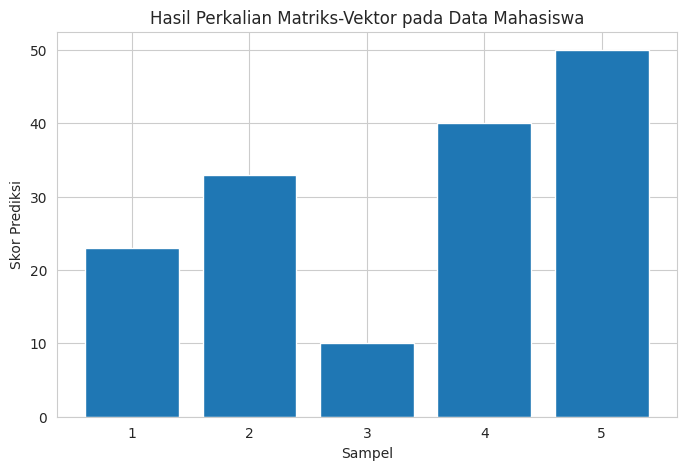

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(scores)+1), scores)
plt.xlabel("Sampel")
plt.ylabel("Skor Prediksi")
plt.title("Hasil Perkalian Matriks-Vektor pada Data Mahasiswa")
plt.show()

## 25. Perkalian Matriks sebagai Transformasi Data

Perkalian matriks tidak hanya menghasilkan angka, tetapi juga dapat dipandang sebagai **transformasi** terhadap data.

Misalnya:
- rotasi titik
- scaling
- shear
- perubahan koordinat

Pada chapter linear algebra, perkalian matriks sering digunakan untuk mengubah posisi vektor dalam ruang.

In [25]:
points = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [3, 2]
])

transform = np.array([
    [2, 0],
    [0, 0.5]
])

transformed_points = points @ transform.T

points_df = pd.DataFrame(points, columns=["x", "y"])
transformed_df = pd.DataFrame(transformed_points, columns=["x_baru", "y_baru"])

print("Titik awal:")
display(points_df)

print("Titik setelah transformasi:")
display(transformed_df)

Titik awal:


,x,y
0,1,1
1,2,1
2,1,2
3,3,2


Titik setelah transformasi:


,x_baru,y_baru
0,2.0,0.5
1,4.0,0.5
2,2.0,1.0
3,6.0,1.0


## 26. Visualisasi Sebelum dan Sesudah Transformasi

Kita plot titik sebelum dan sesudah transformasi agar perubahan posisi lebih jelas.

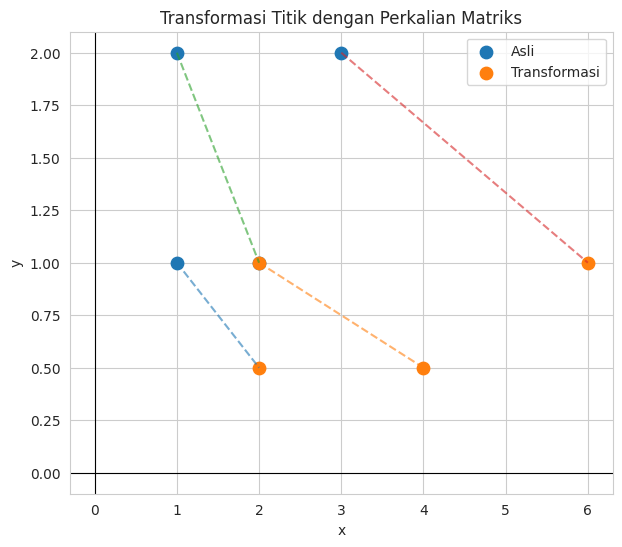

In [26]:
plt.figure(figsize=(7, 6))
plt.scatter(points[:,0], points[:,1], label="Asli", s=80)
plt.scatter(transformed_points[:,0], transformed_points[:,1], label="Transformasi", s=80)

for i in range(len(points)):
    plt.plot(
        [points[i,0], transformed_points[i,0]],
        [points[i,1], transformed_points[i,1]],
        linestyle="--",
        alpha=0.6
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Transformasi Titik dengan Perkalian Matriks")
plt.legend()
plt.grid(True)
plt.show()

## 27. Perkalian Matriks untuk Banyak Sampel Sekaligus

Salah satu keunggulan perkalian matriks adalah efisiensi.  
Daripada menghitung prediksi satu per satu, kita bisa memproses seluruh sampel sekaligus.

Jika:
- ada 10.000 sampel
- setiap sampel punya 20 fitur

maka semua prediksi dapat dihitung sekaligus dengan satu operasi matriks.

In [27]:
np.random.seed(123)

X_large = np.random.randn(100, 5)
w_large = np.random.randn(5)

y_large = X_large @ w_large

print("Shape X_large:", X_large.shape)
print("Shape w_large:", w_large.shape)
print("Shape y_large:", y_large.shape)

print("\n5 prediksi pertama:")
print(y_large[:5])

Shape X_large: (100, 5)
Shape w_large: (5,)
Shape y_large: (100,)

5 prediksi pertama:
[-2.9518  1.2708 -2.0667  0.6668  0.4189]


## 28. Membandingkan Hasil Prediksi Beberapa Sampel

Agar lebih mudah dibaca, kita tampilkan beberapa hasil prediksi dalam DataFrame.

In [28]:
pred_preview = pd.DataFrame(X_large[:10], columns=[f"feature_{i}" for i in range(1, 6)])
pred_preview["prediksi"] = y_large[:10]

pred_preview

,feature_1,feature_2,feature_3,feature_4,feature_5,prediksi
0,-1.085631,0.997345,0.282978,-1.506295,-0.578600,-2.951830
1,1.651437,-2.426679,-0.428913,1.265936,-0.866740,1.270783
2,-0.678886,-0.094709,1.491390,-0.638902,-0.443982,-2.066719
3,-0.434351,2.205930,2.186786,1.004054,0.386186,0.666768
4,0.737369,1.490732,-0.935834,1.175829,-1.253881,0.418868
5,-0.637752,0.907105,-1.428681,-0.140069,-0.861755,-1.253927
6,-0.255619,-2.798589,-1.771533,-0.699877,0.927462,0.601885
7,-0.173636,0.002846,0.688223,-0.879536,0.283627,-0.773067
8,-0.805367,-1.727669,-0.390900,0.573806,0.338589,0.338085
9,-0.011830,2.392365,0.412912,0.978736,2.238143,3.779820


## 29. Ringkasan Aturan Shape Perkalian Matriks

Kita rangkum kembali:

Jika:
- A berukuran `(m, n)`
- B berukuran `(n, p)`

Maka:
- `A @ B` valid
- hasil berukuran `(m, p)`

Jika bagian dalam shape tidak sama, maka perkalian matriks tidak bisa dilakukan.

In [29]:
rules_df = pd.DataFrame({
    "Matriks Pertama": ["2x3", "3x4", "4x2", "5x5"],
    "Matriks Kedua": ["3x2", "4x1", "2x6", "5x3"],
    "Valid?": ["Ya", "Ya", "Ya", "Ya"],
    "Ukuran Hasil": ["2x2", "3x1", "4x6", "5x3"]
})

rules_df

,Matriks Pertama,Matriks Kedua,Valid?,Ukuran Hasil
0,2x3,3x2,Ya,2x2
1,3x4,4x1,Ya,3x1
2,4x2,2x6,Ya,4x6
3,5x5,5x3,Ya,5x3


## 30. Contoh Shape yang Tidak Valid

Sekarang contoh shape yang tidak bisa dikalikan:
- 2×3 dengan 4×2
- 5×2 dengan 3×4
- 3×3 dengan 2×3

In [30]:
invalid_df = pd.DataFrame({
    "Matriks Pertama": ["2x3", "5x2", "3x3"],
    "Matriks Kedua": ["4x2", "3x4", "2x3"],
    "Alasan Tidak Valid": [
        "3 ≠ 4",
        "2 ≠ 3",
        "3 ≠ 2"
    ]
})

invalid_df

,Matriks Pertama,Matriks Kedua,Alasan Tidak Valid
0,2x3,4x2,3 ≠ 4
1,5x2,3x4,2 ≠ 3
2,3x3,2x3,3 ≠ 2


## 31. Kapan Perkalian Matriks Dipakai di Data Science?

Perkalian matriks muncul hampir di semua area machine learning, misalnya:

1. **Linear Regression**
   - menghitung prediksi dari fitur dan bobot

2. **Logistic Regression**
   - menghitung skor linear sebelum fungsi sigmoid

3. **Neural Network**
   - setiap layer dense melakukan perkalian matriks antara input dan bobot

4. **PCA**
   - proyeksi data ke komponen utama

5. **Transformasi fitur**
   - mengubah data dari satu basis ke basis lain

## 32. Kesimpulan

Chapter 5 membahas salah satu operasi terpenting dalam linear algebra, yaitu **perkalian matriks** dan **perkalian matriks-vektor**.

Konsep utama yang dipelajari:
- perbedaan perkalian elemen per elemen dan perkalian matriks,
- aturan shape untuk perkalian matriks,
- penggunaan operator `@`, `np.dot()`, dan `np.matmul()`,
- perkalian matriks-vektor sebagai dasar prediksi linear,
- sifat-sifat dasar perkalian matriks,
- serta hubungan perkalian matriks dengan machine learning dan transformasi data.

Memahami chapter ini sangat penting karena banyak model machine learning pada dasarnya bekerja dengan bentuk:
**X @ w**  
di mana matriks fitur dikalikan dengan vektor parameter untuk menghasilkan prediksi.

In [31]:
print("Chapter 5 selesai dijalankan.")

Chapter 5 selesai dijalankan.
